# DPL Boosting Comparison — Evaluation Notebook

Loads the three previously saved models (LinearSVC, LightGBM, XGBoost) from the `models/`
directory and re-runs the full comparison evaluation **without retraining**.

## Structure
1. Imports
2. Load dataset (test split)
3. Load saved models & compute predictions
4. Compare all three
5. Per-class F1 comparison
6. Confidence scores
7. Feature importance
8. Inference helper

## 1. Imports

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import lightgbm as lgb
import xgboost as xgb
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, f1_score, classification_report

print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")

XGBoost  : 3.2.0
LightGBM : 4.6.0


## 2. Load Dataset (Test Split)

In [2]:
from sklearn.preprocessing import LabelEncoder

DATASETS_DIR = "../datasets"

train_df = pd.read_csv(f"{DATASETS_DIR}/dpl_train.csv")
test_df  = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")

le = LabelEncoder()
le.fit(sorted(train_df["dpl_tag"].unique()))

X_test_raw = test_df["description"].tolist()
y_test     = le.transform(test_df["dpl_tag"])

print(f"Test rows : {len(test_df):,}")
print(f"Classes   : {len(le.classes_)}")

Test rows : 2,272
Classes   : 76


## 3. Load Saved Models & Compute Predictions

In [3]:
_PATHS = {
    "svc":  {"model": "../models/svc_base/model.joblib",  "tfidf": "../models/svc_base/tfidf.joblib",
             "le":    "../models/svc_base/label_encoder.joblib"},
    "lgbm": {"model": "../models/lgbm/model.txt",         "tfidf": "../models/lgbm/tfidf.joblib",
             "le":    "../models/lgbm/label_encoder.joblib"},
    "xgb":  {"model": "../models/xgboost/model.ubj",      "tfidf": "../models/xgboost/tfidf.joblib",
             "svd":   "../models/xgboost/svd.joblib",      "le":    "../models/xgboost/label_encoder.joblib"},
}

_missing = [p for paths in _PATHS.values() for p in paths.values() if not os.path.isfile(p)]
if _missing:
    print("ERROR: Missing model files:")
    for p in _missing:
        print(f"  {p}")
    raise FileNotFoundError("Run the training notebook first.")

# ── LinearSVC ────────────────────────────────────────────────────────────────
# svc_pipe contains only CalibratedClassifierCV (no TF-IDF); apply tfidf first
svc_pipe  = joblib.load(_PATHS["svc"]["model"])
svc_tfidf = joblib.load(_PATHS["svc"]["tfidf"])
X_test_svc = svc_tfidf.transform(X_test_raw)   # sparse TF-IDF matrix
t0 = time.time()
svc_probs = svc_pipe.predict_proba(X_test_svc)
svc_time  = time.time() - t0
svc_preds = svc_probs.argmax(axis=1)
svc_conf  = svc_probs.max(axis=1)
svc_acc   = accuracy_score(y_test, svc_preds)
svc_f1    = f1_score(y_test, svc_preds, average="weighted", zero_division=0)
svc_mac   = f1_score(y_test, svc_preds, average="macro",    zero_division=0)
print(f"LinearSVC  — Acc: {svc_acc:.4f}  Weighted F1: {svc_f1:.4f}")

# ── LightGBM ─────────────────────────────────────────────────────────────────
lgb_bst    = lgb.Booster(model_file=_PATHS["lgbm"]["model"])
lgbm_tfidf = joblib.load(_PATHS["lgbm"]["tfidf"])
X_test_lgbm = lgbm_tfidf.transform(X_test_raw)
t0 = time.time()
lgb_probs = lgb_bst.predict(X_test_lgbm)   # (n, 76)
lgb_time  = time.time() - t0
lgb_preds = lgb_probs.argmax(axis=1)
lgb_conf  = lgb_probs.max(axis=1)
lgb_acc   = accuracy_score(y_test, lgb_preds)
lgb_f1    = f1_score(y_test, lgb_preds, average="weighted", zero_division=0)
lgb_mac   = f1_score(y_test, lgb_preds, average="macro",    zero_division=0)
print(f"LightGBM   — Acc: {lgb_acc:.4f}  Weighted F1: {lgb_f1:.4f}")

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(_PATHS["xgb"]["model"])
xgb_tfidf = joblib.load(_PATHS["xgb"]["tfidf"])
xgb_svd   = joblib.load(_PATHS["xgb"]["svd"])
X_test_xgb = xgb_svd.transform(xgb_tfidf.transform(X_test_raw))   # dense SVD features
t0 = time.time()
xgb_probs = xgb_model.predict_proba(X_test_xgb)
xgb_time  = time.time() - t0
xgb_preds = xgb_probs.argmax(axis=1)
xgb_conf  = xgb_probs.max(axis=1)
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_f1    = f1_score(y_test, xgb_preds, average="weighted", zero_division=0)
xgb_mac   = f1_score(y_test, xgb_preds, average="macro",    zero_division=0)
print(f"XGBoost    — Acc: {xgb_acc:.4f}  Weighted F1: {xgb_f1:.4f}")

results = {
    "LinearSVC": {"acc": svc_acc, "f1w": svc_f1, "f1m": svc_mac,
                  "time": svc_time, "probs": svc_probs, "preds": svc_preds, "conf": svc_conf},
    "LightGBM":  {"acc": lgb_acc, "f1w": lgb_f1, "f1m": lgb_mac,
                  "time": lgb_time, "probs": lgb_probs, "preds": lgb_preds, "conf": lgb_conf},
    "XGBoost":   {"acc": xgb_acc, "f1w": xgb_f1, "f1m": xgb_mac,
                  "time": xgb_time, "probs": xgb_probs, "preds": xgb_preds, "conf": xgb_conf},
}
print("\nAll models loaded.")

LinearSVC  — Acc: 0.9996  Weighted F1: 0.9996
LightGBM   — Acc: 0.9974  Weighted F1: 0.9974
XGBoost    — Acc: 0.9947  Weighted F1: 0.9947

All models loaded.


## 4. Compare All Three

           Accuracy  Weighted F1  Macro F1  Inference time (s)  Mean confidence
Model                                                                          
LinearSVC    0.9996       0.9996    0.9996              0.0500           0.9777
LightGBM     0.9974       0.9974    0.9974              0.1880           0.9943
XGBoost      0.9947       0.9947    0.9947              0.1130           0.9668


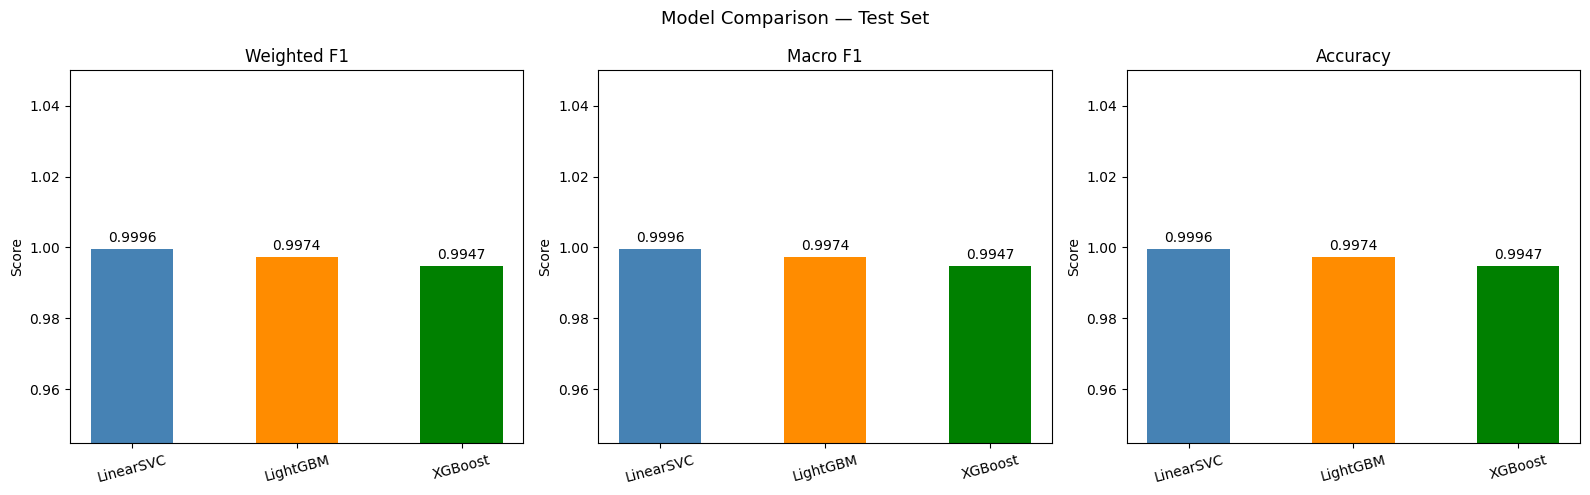

In [4]:
colors = ["steelblue", "darkorange", "green"]

summary = pd.DataFrame([
    {"Model": k, "Accuracy": v["acc"], "Weighted F1": v["f1w"],
     "Macro F1": v["f1m"], "Inference time (s)": round(v["time"], 3),
     "Mean confidence": round(v["conf"].mean(), 4)}
    for k, v in results.items()
]).set_index("Model")

print(summary.to_string(float_format="{:.4f}".format))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, title) in zip(axes, [
    ("Weighted F1", "Weighted F1"), ("Macro F1", "Macro F1"), ("Accuracy", "Accuracy"),
]):
    bars = ax.bar(summary.index, summary[metric], color=colors, width=0.5)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_ylim(max(0, summary[metric].min() - 0.05), 1.05)
    ax.set_title(title); ax.set_ylabel("Score"); ax.tick_params(axis="x", rotation=15)
plt.suptitle("Model Comparison — Test Set", fontsize=13)
plt.tight_layout(); plt.show()

## 5. Per-class F1 Comparison

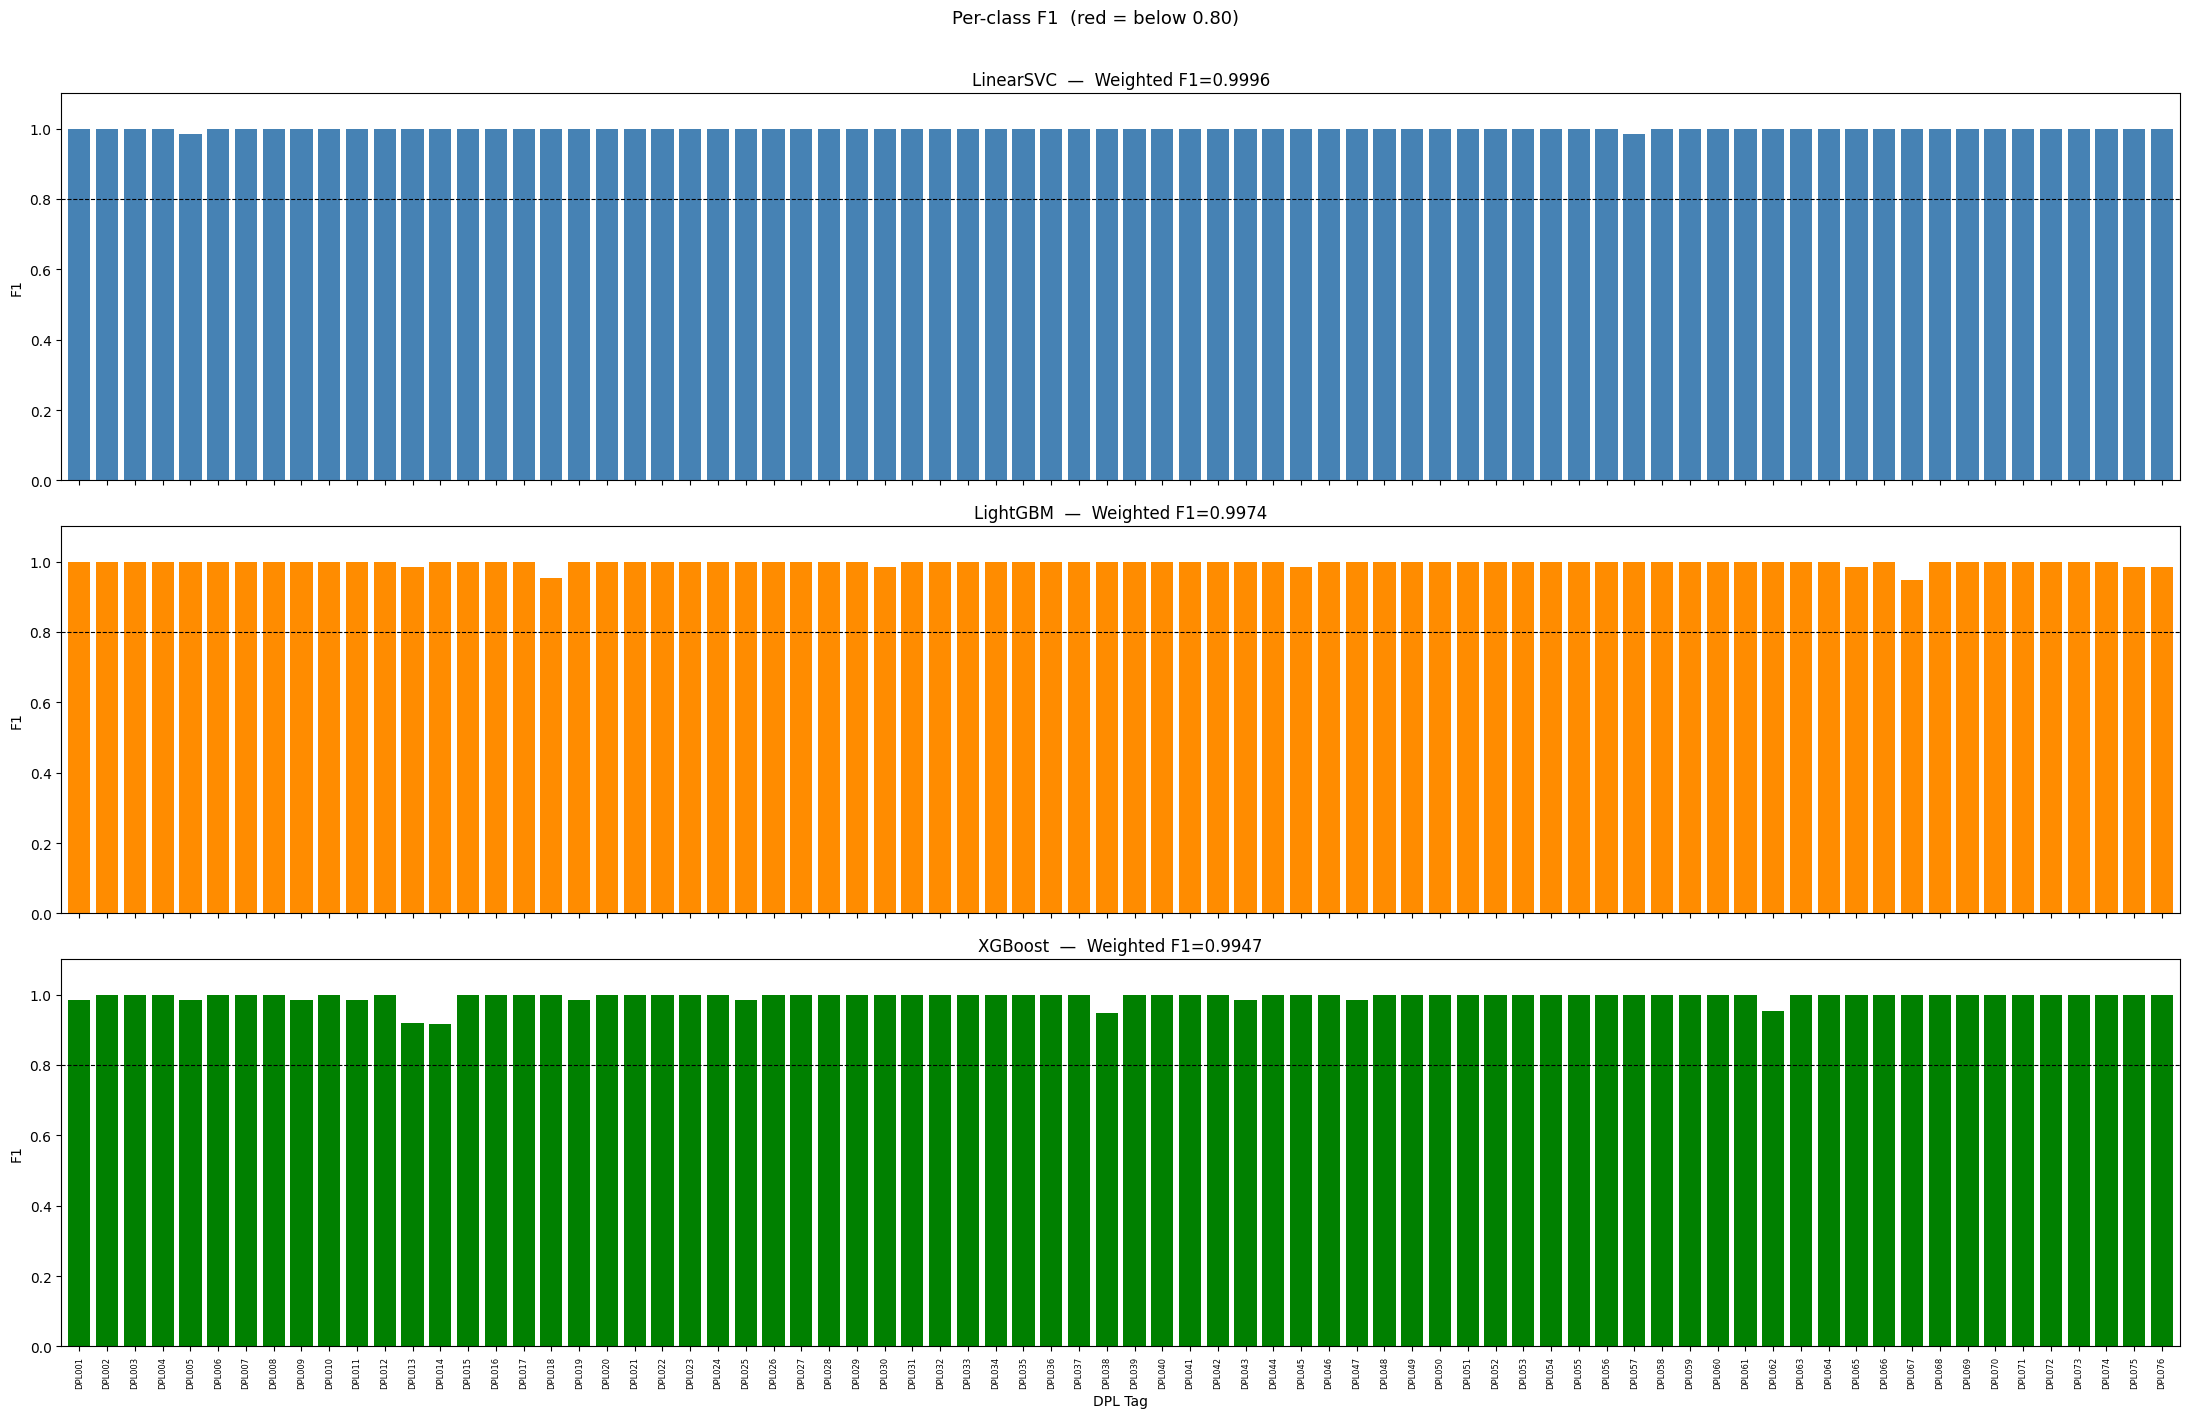

In [5]:
tag_names   = le.classes_.tolist()
true_labels = le.inverse_transform(y_test)

per_class = {}
for name, v in results.items():
    rep = classification_report(
        true_labels, le.inverse_transform(v["preds"]), output_dict=True, zero_division=0,
    )
    per_class[name] = pd.Series(
        {t: rep[t]["f1-score"] for t in tag_names if t in rep}
    ).sort_index()

fig, axes = plt.subplots(3, 1, figsize=(22, 14), sharex=True)
for ax, (name, f1s), color in zip(axes, per_class.items(), colors):
    bar_colors = ["#d62728" if v < 0.80 else color for v in f1s.values]
    f1s.plot(kind="bar", ax=ax, color=bar_colors, width=0.8)
    ax.axhline(0.80, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name}  —  Weighted F1={results[name]['f1w']:.4f}")
    ax.set_ylabel("F1"); ax.set_ylim(0, 1.1); ax.tick_params(axis="x", labelsize=6)
axes[-1].set_xlabel("DPL Tag")
plt.suptitle("Per-class F1  (red = below 0.80)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [6]:
weak_all = [t for t in tag_names if all(per_class[m].get(t, 0) < 0.80 for m in results)]
print(f"Tags below F1=0.80 in ALL three models ({len(weak_all)}):")
if weak_all:
    weak_df = pd.DataFrame(
        {m: [per_class[m].get(t, 0) for t in weak_all] for m in results}, index=weak_all
    ).round(4)
    print(weak_df.to_string())
else:
    print("  None — all models exceed F1=0.80 on every tag.")

Tags below F1=0.80 in ALL three models (0):
  None — all models exceed F1=0.80 on every tag.


## 6. Confidence Scores

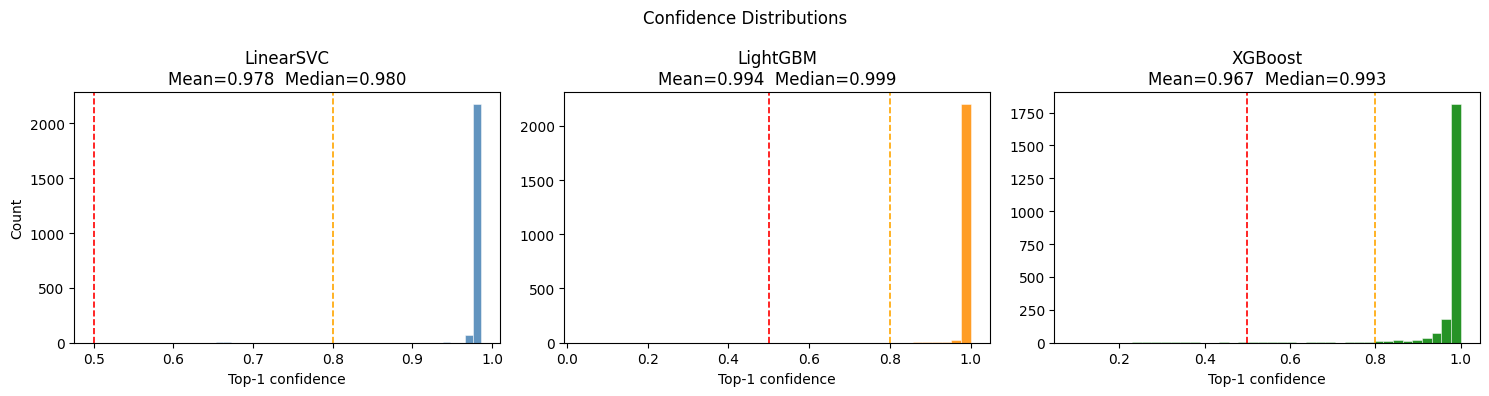

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, v), color in zip(axes, results.items(), colors):
    conf = v["conf"]
    ax.hist(conf, bins=40, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(0.50, color="red",    linestyle="--", linewidth=1.2)
    ax.axvline(0.80, color="orange", linestyle="--", linewidth=1.2)
    ax.set_title(f"{name}\nMean={conf.mean():.3f}  Median={np.median(conf):.3f}")
    ax.set_xlabel("Top-1 confidence")
axes[0].set_ylabel("Count")
plt.suptitle("Confidence Distributions")
plt.tight_layout(); plt.show()

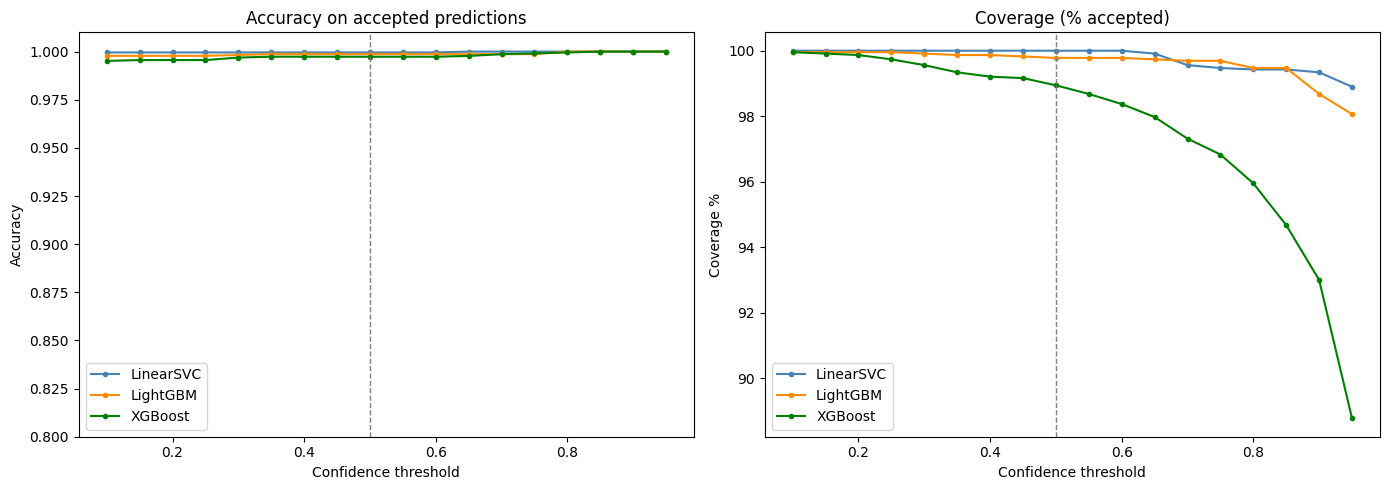

In [8]:
thresholds = np.arange(0.1, 1.0, 0.05)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, v, color in zip(results, results.values(), colors):
    conf = v["conf"]; preds = v["preds"]
    accs, covs = [], []
    for t in thresholds:
        mask = conf >= t
        if mask.sum() == 0: break
        accs.append(accuracy_score(y_test[mask], preds[mask]))
        covs.append(mask.mean() * 100)
    ax1.plot(thresholds[:len(accs)], accs, "-o", color=color, markersize=3, label=name)
    ax2.plot(thresholds[:len(covs)], covs, "-o", color=color, markersize=3, label=name)
for ax in (ax1, ax2):
    ax.axvline(0.50, color="grey", linestyle="--", linewidth=1)
    ax.legend(); ax.set_xlabel("Confidence threshold")
ax1.set_title("Accuracy on accepted predictions"); ax1.set_ylabel("Accuracy"); ax1.set_ylim(0.8, 1.01)
ax2.set_title("Coverage (% accepted)"); ax2.set_ylabel("Coverage %")
plt.tight_layout(); plt.show()

## 7. Feature Importance

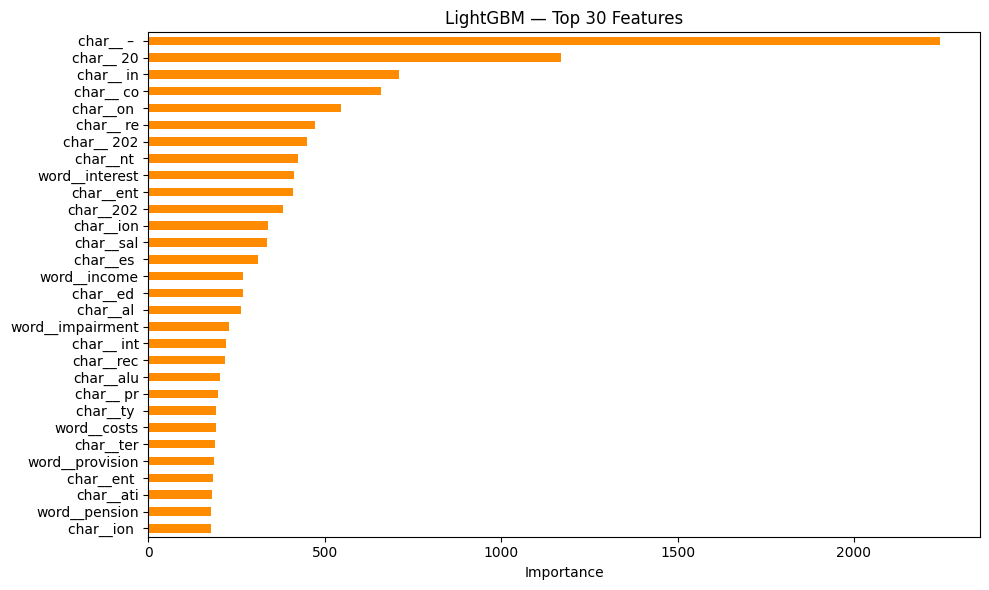

char__ –            2245
char__ 20           1169
char__ in            710
char__ co            659
char__on             545
char__ re            471
char__ 202           449
char__nt             425
word__interest       412
char__ent            411
char__202            382
char__ion            339
char__sal            335
char__es             310
word__income         269
char__ed             267
char__al             263
word__impairment     229
char__ int           219
char__rec            218
char__alu            202
char__ pr            197
char__ty             191
word__costs          191
char__ter            190
word__provision      185
char__ent            182
char__ati            180
word__pension        176
char__ion            176


In [9]:
# LightGBM — feature importance by split
lgbm_tfidf_loaded = joblib.load("../models/lgbm/tfidf.joblib")
word_features = lgbm_tfidf_loaded.transformer_list[0][1].get_feature_names_out()
char_features = lgbm_tfidf_loaded.transformer_list[1][1].get_feature_names_out()
feature_names = np.concatenate(
    [[f"word__{f}" for f in word_features], [f"char__{f}" for f in char_features]]
)

lgb_importance = pd.Series(lgb_bst.feature_importance(importance_type="split"), index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
lgb_importance.head(30).plot(kind="barh", ax=ax, color="darkorange")
ax.invert_yaxis(); ax.set_title("LightGBM — Top 30 Features")
ax.set_xlabel("Importance"); plt.tight_layout(); plt.show()
print(lgb_importance.head(30).to_string())

## 8. Inference Helper

In [10]:
def predict_lgbm(descriptions, top_k=3, model_dir="../models/lgbm"):
    _tfidf = joblib.load(f"{model_dir}/tfidf.joblib")
    _le    = joblib.load(f"{model_dir}/label_encoder.joblib")
    _model = lgb.Booster(model_file=f"{model_dir}/model.txt")
    X      = _tfidf.transform(descriptions)
    probs  = _model.predict(X)
    return [{
        "description": desc,
        "top_prediction": {"tag": _le.classes_[probs[i].argmax()], "confidence": round(float(probs[i].max()), 4)},
        "top_k": [{"tag": _le.classes_[j], "confidence": round(float(probs[i][j]), 4)}
                  for j in np.argsort(probs[i])[::-1][:top_k]],
    } for i, desc in enumerate(descriptions)]

def predict_svc(descriptions, top_k=3, model_dir="../models/svc_base"):
    _tfidf = joblib.load(f"{model_dir}/tfidf.joblib")
    _pipe  = joblib.load(f"{model_dir}/model.joblib")
    _le    = joblib.load(f"{model_dir}/label_encoder.joblib")
    X      = _tfidf.transform(descriptions)
    probs  = _pipe.predict_proba(X)
    return [{
        "description": desc,
        "top_prediction": {"tag": _le.classes_[probs[i].argmax()], "confidence": round(float(probs[i].max()), 4)},
        "top_k": [{"tag": _le.classes_[j], "confidence": round(float(probs[i][j]), 4)}
                  for j in np.argsort(probs[i])[::-1][:top_k]],
    } for i, desc in enumerate(descriptions)]

def predict_xgb(descriptions, top_k=3, model_dir="../models/xgboost"):
    _tfidf = joblib.load(f"{model_dir}/tfidf.joblib")
    _svd   = joblib.load(f"{model_dir}/svd.joblib")
    _le    = joblib.load(f"{model_dir}/label_encoder.joblib")
    _model = xgb.XGBClassifier()
    _model.load_model(f"{model_dir}/model.ubj")
    X     = _svd.transform(_tfidf.transform(descriptions))
    probs = _model.predict_proba(X)
    return [{
        "description": desc,
        "top_prediction": {"tag": _le.classes_[probs[i].argmax()], "confidence": round(float(probs[i].max()), 4)},
        "top_k": [{"tag": _le.classes_[j], "confidence": round(float(probs[i][j]), 4)}
                  for j in np.argsort(probs[i])[::-1][:top_k]],
    } for i, desc in enumerate(descriptions)]


def _print_results(model_name, results):
    print(f"\n=== {model_name} ===")
    print(f"  {'Description':<55}  {'Top-1':>8}   Score    Alt. #2 & #3")
    print("  " + "-" * 110)
    for r in results:
        top1 = r["top_prediction"]
        alts = "  |  ".join(
            f"{t['tag']} ({t['confidence']:.3f})" for t in r["top_k"][1:]
        )
        print(f"  {r['description']:<55}  {top1['tag']:>8}   {top1['confidence']:.3f}    {alts}")


test_descs = [
    "INV-55234 \u2013 Deloitte audit services FY2025",
    "Monthly payroll \u2013 March 2026 \u2013 Finance",
    "Interest charged on HSBC overdraft \u2013 January",
    "Google Ads campaign \u2013 Q2 2026",
    "Office rent \u2013 London HQ \u2013 April 2026",
    "Redundancy costs \u2013 IT department \u2013 2025",
    "KPMG tax advisory fees",
    "AWS cloud hosting \u2013 February subscription",
    "Staff Christmas party expense \u2013 2025",
    "FX loss on USD settlement \u2013 AP-78341",
]

In [11]:
_print_results("LinearSVC", predict_svc(test_descs))


=== LinearSVC ===
  Description                                                 Top-1   Score    Alt. #2 & #3
  --------------------------------------------------------------------------------------------------------------
  INV-55234 – Deloitte audit services FY2025                 DPL003   0.978    DPL040 (0.001)  |  DPL051 (0.001)
  Monthly payroll – March 2026 – Finance                     DPL068   0.976    DPL058 (0.005)  |  DPL057 (0.004)
  Interest charged on HSBC overdraft – January               DPL035   0.980    DPL076 (0.001)  |  DPL050 (0.001)
  Google Ads campaign – Q2 2026                              DPL001   0.979    DPL028 (0.001)  |  DPL029 (0.001)
  Office rent – London HQ – April 2026                       DPL055   0.979    DPL029 (0.001)  |  DPL022 (0.001)
  Redundancy costs – IT department – 2025                    DPL059   0.983    DPL027 (0.001)  |  DPL051 (0.001)
  KPMG tax advisory fees                                     DPL003   0.977    DPL038 (0.001)  |  

In [12]:
_print_results("LightGBM", predict_lgbm(test_descs))


=== LightGBM ===
  Description                                                 Top-1   Score    Alt. #2 & #3
  --------------------------------------------------------------------------------------------------------------
  INV-55234 – Deloitte audit services FY2025                 DPL003   0.999    DPL001 (0.000)  |  DPL049 (0.000)
  Monthly payroll – March 2026 – Finance                     DPL068   0.999    DPL057 (0.000)  |  DPL003 (0.000)
  Interest charged on HSBC overdraft – January               DPL035   0.999    DPL076 (0.000)  |  DPL006 (0.000)
  Google Ads campaign – Q2 2026                              DPL001   0.999    DPL053 (0.000)  |  DPL069 (0.000)
  Office rent – London HQ – April 2026                       DPL055   0.998    DPL059 (0.000)  |  DPL062 (0.000)
  Redundancy costs – IT department – 2025                    DPL059   0.997    DPL048 (0.001)  |  DPL056 (0.001)
  KPMG tax advisory fees                                     DPL003   0.992    DPL031 (0.002)  |  D

In [13]:
_print_results("XGBoost", predict_xgb(test_descs))


=== XGBoost ===
  Description                                                 Top-1   Score    Alt. #2 & #3
  --------------------------------------------------------------------------------------------------------------
  INV-55234 – Deloitte audit services FY2025                 DPL003   0.985    DPL061 (0.001)  |  DPL065 (0.001)
  Monthly payroll – March 2026 – Finance                     DPL068   0.612    DPL070 (0.087)  |  DPL073 (0.023)
  Interest charged on HSBC overdraft – January               DPL035   0.995    DPL006 (0.001)  |  DPL076 (0.001)
  Google Ads campaign – Q2 2026                              DPL001   0.996    DPL053 (0.001)  |  DPL074 (0.000)
  Office rent – London HQ – April 2026                       DPL055   0.990    DPL002 (0.001)  |  DPL066 (0.001)
  Redundancy costs – IT department – 2025                    DPL059   0.991    DPL056 (0.001)  |  DPL042 (0.000)
  KPMG tax advisory fees                                     DPL003   0.984    DPL038 (0.003)  |  DP